In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [ ]:
# Step 1: Load the dataset from a CSV file
# Replace 'data.csv' with the path to your CSV file
df = pd.read_csv('/content/Iris.csv')

# Display the first few rows of the dataset
print("Loaded Data:")
print(df.head())

# Step 2: Prepare the data
# Assuming the last column is the target variable
X = df.iloc[:, :-1].values  # All columns except the last
y = df.iloc[:, -1].values    # The last column as target

# Convert to DataFrame for easier manipulation (optional)
feature_names = df.columns[:-1]
df['target'] = y

# Step 3: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Print the standardized data
print("\nStandardized Data:")
print(pd.DataFrame(X_scaled, columns=feature_names).head())





Loaded Data:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Standardized Data:
         Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0 -1.720542      -0.900681      1.032057      -1.341272     -1.312977
1 -1.697448      -1.143017     -0.124958      -1.341272     -1.312977
2 -1.674353      -1.385353      0.337848      -1.398138     -1.312977
3 -1.651258      -1.506521      0.106445      -1.284407     -1.312977
4 -1.628164      -1.021849      1.263460      -1.341272     -1.312977


In [ ]:
# Step 4: Implement PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Step 5: Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained variance ratio:")
print(explained_variance_ratio)

# Step 6: Eigenvalues and Eigenvectors
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)


Explained variance ratio:
[0.7470533  0.18435257 0.04682624 0.01764767 0.00412021]

Eigenvalues:
[3.7603354  0.92794917 0.23570257 0.08883057 0.02073933]

Eigenvectors:
[[ 0.48136016  0.44844975 -0.23195044  0.51079205  0.5024696 ]
 [-0.02275157  0.38285827  0.92007839  0.03074857  0.07356757]
 [ 0.67406853 -0.64520569  0.27427786 -0.13238322  0.19127876]
 [-0.55978662 -0.40999945  0.09491665  0.28817343  0.65305918]
 [ 0.0067323  -0.26061932  0.12416613  0.79848404 -0.52824072]]


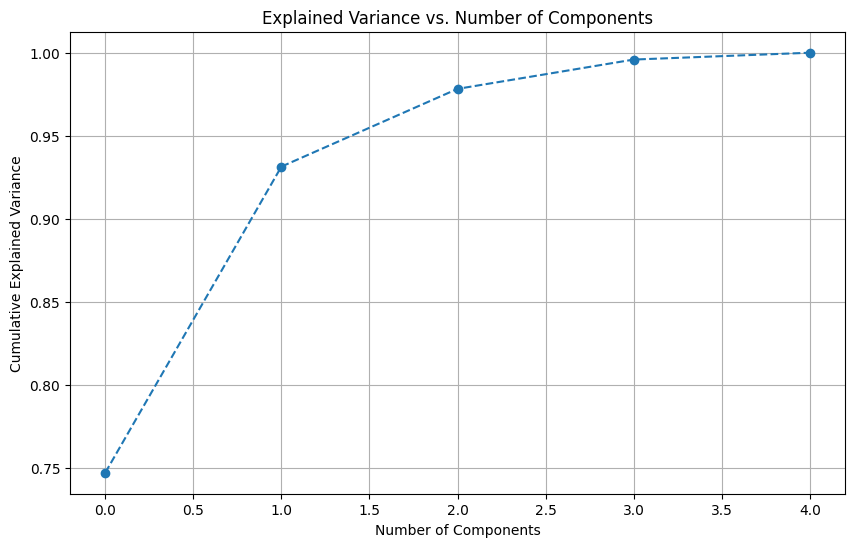

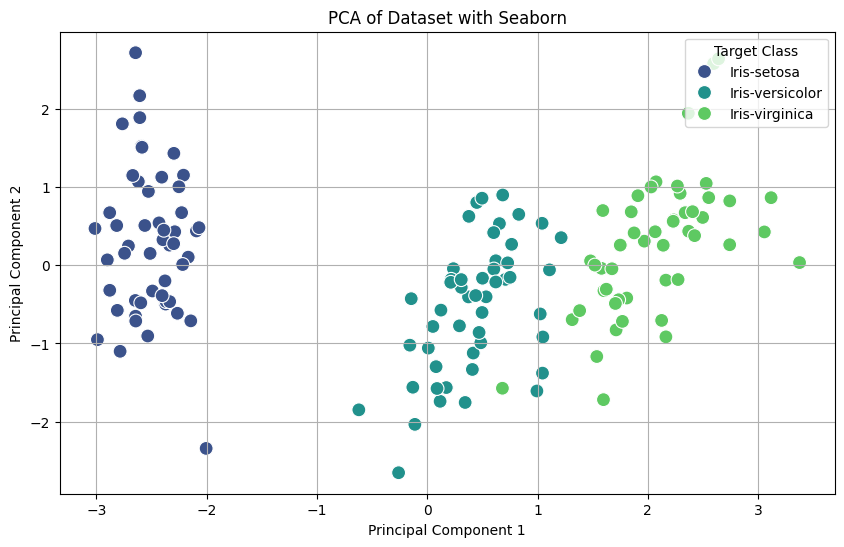

In [ ]:
# Step 7: Scree plot of explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()




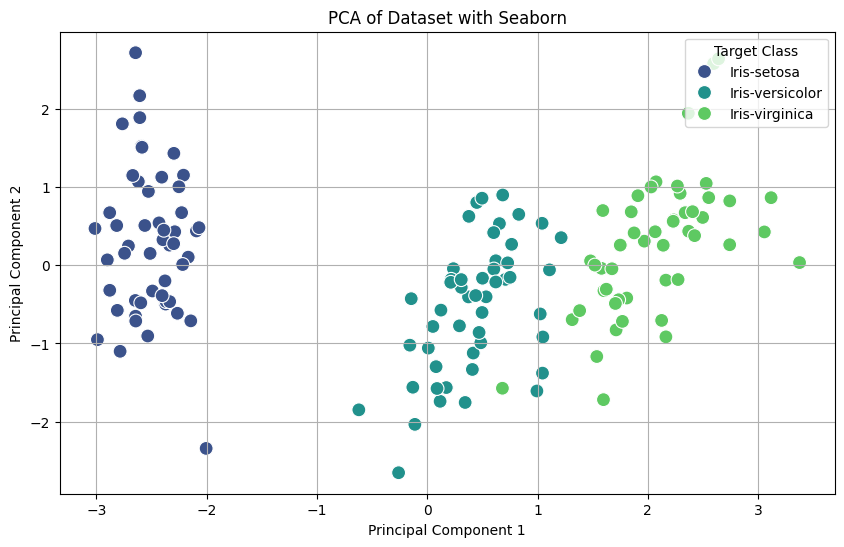

In [ ]:
# Step 8: Visualize the first two principal components with Seaborn
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['target'] = y

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='target', palette='viridis', data=pca_df, s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Dataset with Seaborn')
plt.legend(title='Target Class', loc='upper right')
plt.grid(True)
plt.show()